# EDA: March Madness Upsets by Seed Matchup

In this analysis, we explore how often different seed matchups result in upsets in the NCAA tournament. In particular, we examine whether 12-seed upsets are more common compared to other matchups.

We expect that 12-seed upsets occur more frequently than many other seed matchups, making them one of the most common upset types in the tournament.

## Part 1: Data Setup & Preparation

We begin by loading the dataset and examining its structure to understand what information is available.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

### 1a. Inspecting the Data

We begin by loading the dataset and examining its structure. This helps us understand what variables are available and how the data is organized.

In [3]:
df = pd.read_csv("/Users/brandonratsamy/St Thomas Grad School/SEIS 631 - Data Prep and Analysis/march-madness-upset-analysis-UST-631/archive/Upset Seed Info.csv")

df.head()

,YEAR,CURRENT ROUND,SEED WON,SEED LOST,SEED DIFF
0,2025,64,10,7,3
1,2025,64,12,5,7
2,2025,64,11,6,5
3,2025,64,10,7,3
4,2025,64,12,5,7


In [4]:
df.columns

Index(['YEAR', 'CURRENT ROUND', 'SEED WON', 'SEED LOST', 'SEED DIFF'], dtype='object')

In [5]:
df.shape

(229, 5)

The dataset contains information about upset matchups in March Madness, including the winning and losing seeds. Each row represents an upset game.

### Part 2. Identifying Key Variables

We identify the variables needed for our analysis, including team seeds and game outcomes.

In [6]:
df.head()

,YEAR,CURRENT ROUND,SEED WON,SEED LOST,SEED DIFF
0,2025,64,10,7,3
1,2025,64,12,5,7
2,2025,64,11,6,5
3,2025,64,10,7,3
4,2025,64,12,5,7


We focus on the seed matchup and whether the game resulted in an upset.

## Part 3: Filtering 12 vs 5 Upsets

We filter the dataset to include only upset games where a 12-seed defeated a 5-seed.

In [7]:
df.columns

Index(['YEAR', 'CURRENT ROUND', 'SEED WON', 'SEED LOST', 'SEED DIFF'], dtype='object')

In [8]:
# Filter 12 vs 5 matchups
df_12v5 = df[
    (df["SEED WON"] == 12) & (df["SEED LOST"] == 5)
]

df_12v5.head()

,YEAR,CURRENT ROUND,SEED WON,SEED LOST,SEED DIFF
1,2025,64,12,5,7
4,2025,64,12,5,7
12,2024,64,12,5,7
13,2024,64,12,5,7
36,2022,64,12,5,7


In [9]:
df_12v5.shape

(28, 5)

This subset includes all games where a 12-seed and a 5-seed played each other. This allows us to analyze how often 12-seeds win these matchups.

## Part 4: Exploring Upset Outcomes

In [10]:
df_12v5.shape

(28, 5)

In [11]:
df.groupby(["SEED WON", "SEED LOST"]).size().sort_values(ascending=False)

SEED WON  SEED LOST
11        6            33
12        5            28
10        7            27
13        4            15
11        3            12
7         2            11
4         1             8
14        3             8
6         3             8
15        2             7
8         1             7
5         1             6
10        2             6
8         2             4
15        7             4
7         3             4
12        4             3
3         1             3
5         2             3
11        2             3
9         1             3
8         4             3
7         4             3
9         4             2
6         2             2
11        1             2
16        1             2
4         2             1
7         1             1
9         2             1
          5             1
10        3             1
          1             1
9         3             1
11        4             1
          9             1
          7             1
12        8       

We count the number of upset matchups to identify which seed combinations occur most frequently.

## Part 5: Visualization

We visualize the most common upset matchups to better understand patterns in the data.

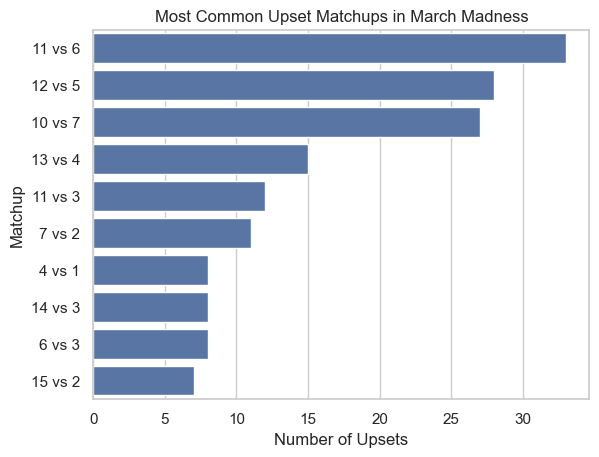

In [12]:
top_matchups = df.groupby(["SEED WON", "SEED LOST"]).size().reset_index(name="count")

top_matchups = top_matchups.sort_values(by="count", ascending=False).head(10)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top_matchups, x="count", y=top_matchups["SEED WON"].astype(str) + " vs " + top_matchups["SEED LOST"].astype(str))

plt.title("Most Common Upset Matchups in March Madness")
plt.xlabel("Number of Upsets")
plt.ylabel("Matchup")


plt.show()

The analysis showed that 11 vs 6 upsets occurred most frequently in the dataset, while 12 vs 5 upsets were the second most common. Although 12 vs 5 matchups are widely discussed in March Madness, the data suggests that 11 vs 6 upsets may happen even more often.

## Summary

The exploratory analysis shows that 12 vs 5 upsets appear frequently in this dataset. There are 28 recorded 12 vs 5 upsets, making it the second most common upset matchup in the data behind 11 vs 6. The bootstrap confidence interval suggests that 12 vs 5 upsets make up about 8.3% to 16.6% of all upset games in this dataset.

Because this dataset only includes upset games, this analysis cannot measure the true probability of a 12-seed beating a 5-seed. Instead, it shows that among recorded upsets, 12 vs 5 is one of the most common patterns.

## Hypothesis Test

We want to test whether 12 vs 5 upsets occur more frequently than other upset matchups.

Null hypothesis (H₀): 12 vs 5 upsets occur at the same rate as other matchups  
Alternative hypothesis (H₁): 12 vs 5 upsets occur more frequently than other matchups  

In [13]:
# Create a matchup label
df["matchup"] = df["SEED WON"].astype(str) + " vs " + df["SEED LOST"].astype(str)

# Indicator for 12 vs 5
df["is_12v5"] = ((df["SEED WON"] == 12) & (df["SEED LOST"] == 5)).astype(int)

# Observed statistic
obs_stat = df["is_12v5"].mean()
obs_stat

np.float64(0.1222707423580786)

In [14]:
import numpy as np

results = []

for _ in range(5000):
    shuffled = df["is_12v5"].sample(frac=1, replace=False).reset_index(drop=True)
    stat = shuffled.mean()
    results.append(stat)

# p-value
p_value = np.mean(np.array(results) >= obs_stat)
p_value

np.float64(1.0)

We shuffle the matchup labels to simulate what would happen if matchup type did not matter. We then compare our observed statistic to this simulated distribution.

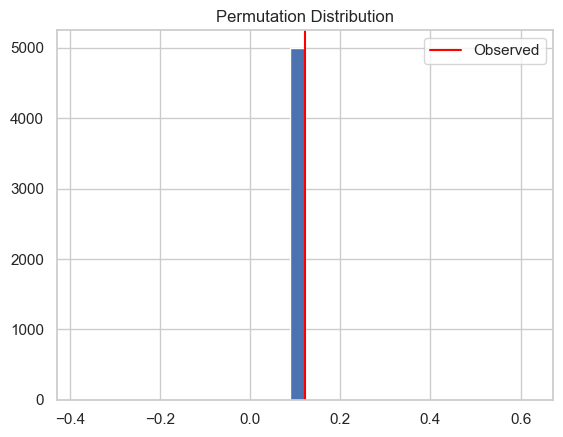

In [15]:
import matplotlib.pyplot as plt

plt.hist(results, bins=30)
plt.axvline(obs_stat, color='red', label='Observed')
plt.title("Permutation Distribution")
plt.legend()
plt.show()

This is Bootstrapping

In [16]:
boot_stats = []

for _ in range(5000):
    sample = df.sample(frac=1, replace=True)
    stat = sample["is_12v5"].mean()
    boot_stats.append(stat)

# confidence interval
np.percentile(boot_stats, [2.5, 97.5])

array([0.08296943, 0.16593886])

We use bootstrapping to estimate the variability of our statistic. This allows us to build a confidence interval without relying on normal assumptions.

The Central Limit Theorem may not fully apply here because we are working with a specific subset of matchups rather than a simple mean of independent observations. Therefore, bootstrapping provides a more reliable estimate of uncertainty.

## Conclusion

The exploratory analysis showed that 11 vs 6 upsets occurred most frequently in the dataset, while 12 vs 5 upsets were the second most common upset matchup. This suggests that although 12 vs 5 games are well known for producing upsets, 11 vs 6 matchups may actually occur more often.

The bootstrap confidence interval suggests that 12 vs 5 upsets make up about 8.3% to 16.6% of all upset games in the dataset.

Because the dataset only contains upset games, this analysis cannot estimate the true probability of a 12-seed beating a 5-seed. However, it does show that both 11 vs 6 and 12 vs 5 are recurring upset patterns in March Madness.

## Final Interpretation

The analysis showed that 11 vs 6 upsets occurred most frequently in the dataset, while 12 vs 5 upsets were the second most common matchup. This suggests that although 12 vs 5 games are widely known for producing upsets, 11 vs 6 upsets may happen even more often.

The bootstrap confidence interval suggests that 12 vs 5 upsets make up roughly 8% to 17% of all upset games in the dataset. This indicates that these matchups are a meaningful and recurring pattern in March Madness.

## Limitations

One limitation of this analysis is that the dataset only includes upset games, not all tournament games. Because of this, the project cannot calculate the true probability of a 12-seed defeating a 5-seed. Instead, the analysis focuses on how often different upset matchups appear relative to one another.